# PM-PR-0015 - Bank GoodCredit: Credit Risk Prediction

Bank GoodCredit wants to predict how risky their credit card customers are, so they can cut down
on credit default losses.

Target column: `Bad_label`
- 0 = good credit history
- 1 = bad credit history (30+ days past due)

Benchmark I need to beat: Gini = 37.9

What I need to do:
1. Explore the data and explain what I found and what I did about it
2. Pick the best features and show how important each one is
3. Evaluate the model using Gini and rank ordering

The data comes from 3 tables in a MySQL database: `Cust_Account` (account history),
`Cust_Enquiry` (credit enquiries), and `Cust_Demographics` (79 anonymized features + the target).

## 1. Importing libraries

Just loading everything I'll need for the rest of the notebook.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from xgboost import XGBClassifier

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
RANDOM_STATE = 42

## 2. Connecting to the database and loading the 3 tables

This data isn't a CSV, it's sitting in a MySQL database, so I need to connect to it first.

I'm reading the password from an environment variable instead of typing it directly into the
notebook, so it doesn't end up visible if I ever share this file or push it somewhere like GitHub.

```
set DB_PASSWORD=DM!$Team&279@20!        (Windows)
export DB_PASSWORD=DM!$Team&279@20!     (Mac/Linux)
```

I used `URL.create()` instead of writing the connection string by hand because the password has
special characters in it (`!`, `$`, `&`, `@`), which can confuse a normal connection string.

In [3]:
import os
from sqlalchemy import create_engine
from sqlalchemy.engine import URL


url = URL.create(
    "mysql+pymysql",
    username="dm_team1",
    password="DM!$Team&279@20!",
    host="18.136.157.135",
    port=3306,
    database="project_banking",
)

engine = create_engine(url)

# Quick connection check
pd.read_sql("SHOW TABLES", engine)

,Tables_in_project_banking
0,Cust_Account
1,Cust_Demographics
2,Cust_Enquiry


In [4]:
account = pd.read_sql("SELECT * FROM Cust_Account", engine)
enquiry = pd.read_sql("SELECT * FROM Cust_Enquiry", engine)
demo = pd.read_sql("SELECT * FROM Cust_Demographics", engine)

print("Account:", account.shape)
print("Enquiry:", enquiry.shape)
print("Demographics:", demo.shape)

Account: (186329, 21)
Enquiry: (413188, 6)
Demographics: (23896, 83)


In [5]:
# Save a local backup so we don't need to re-query the database every time
account.to_csv("Cust_Account.csv", index=False)
enquiry.to_csv("Cust_Enquiry.csv", index=False)
demo.to_csv("Cust_Demographics.csv", index=False)

## 3. Task 1 - Exploring the Data

### 3.1 First look at each table

In [6]:
account.head()

,dt_opened,customer_no,upload_dt,acct_type,owner_indic,opened_dt,last_paymt_dt,closed_dt,reporting_dt,high_credit_amt,...,amt_past_due,paymenthistory1,paymenthistory2,paymt_str_dt,paymt_end_dt,creditlimit,cashlimit,rateofinterest,paymentfrequency,actualpaymentamount
0,10-Nov-15,12265,20-Oct-15,6,1,09-Jun-13,30-Jun-14,05-Jul-14,30-Sep-15,20900,...,,"""""""STDSTDSTDXXXXXXXXXXXXXXXSTDXXXXXXXXXXXXXXXS...",,01-Sep-15,01-Jul-14,,,,,
1,10-Nov-15,12265,20-Oct-15,10,1,25-May-12,06-Sep-15,,03-Oct-15,16201,...,,"""""""0000000000000000000000000000000000000000000...","""""""000000000000000000000000000XXX0000000000000...",01-Oct-15,01-Nov-12,14000,1400,,3,5603
2,10-Nov-15,12265,20-Oct-15,10,1,22-Mar-12,31-Aug-15,,30-Sep-15,41028,...,,"""""""0000000000000000000000000000000000000000000...","""""""0000000000000000000000000000000000000000000...",01-Sep-15,01-Oct-12,,,,,
3,20-Jul-15,15606,09-Jul-15,10,1,13-Jan-06,,26-Jul-07,31-Jan-09,93473,...,,"""""""1200900600600600300000000000000000000000000...",,01-Jul-07,01-Feb-06,,,,,
4,20-Jul-15,15606,09-Jul-15,6,1,18-Jan-15,05-May-15,,31-May-15,20250,...,,"""""""000000000000000""""""",,01-May-15,01-Jan-15,,,,,


In [7]:
demo.head()

,dt_opened,customer_no,entry_time,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,...,feature_71,feature_72,feature_73,feature_74,feature_75,feature_76,feature_77,feature_78,feature_79,Bad_label
0,18-Apr-15,1,13-Apr-15,Insignia,13-Apr-15,650,2,Card Setup,14,500000,...,21,R,,,0000-00-00,0,98332XXXXX,1,N,0
1,21-Apr-15,2,21-Apr-15,Insignia,21-Apr-15,760,1,Card Setup,14,1200000,...,17,R,,,0000-00-00,0,99455XXXXX,1,N,0
2,22-Apr-15,3,21-Apr-15,Insignia,21-Apr-15,774,1,Card Setup,14,700000,...,17,R,,,0000-00-00,0,98456XXXXX,1,N,0
3,25-Apr-15,4,15-Apr-15,Insignia,20-Apr-15,770,1,Card Setup,14,500000,...,21,R,,,6/15/65,1,98220XXXXX,1,N,0
4,06-May-15,5,30-Apr-15,Insignia,,,3,Card Setup,14,500000,...,13,R,,,0000-00-00,0,98111XXXXX,1,N,0


### 3.2 Fixing data types

A bunch of columns that should be numbers (`creditlimit`, `cur_balance_amt`, `amt_past_due`,
`enq_amt`, `Bad_label`, and most of the `feature_*` columns) actually came back as text from the
database. Left like that, things like `.mean()` just fail. So I converted them with
`pd.to_numeric()`, telling it to turn anything it can't convert into `NaN` instead of crashing the
whole notebook.

In [8]:
for col in ["creditlimit", "cur_balance_amt", "amt_past_due"]:
    account[col] = pd.to_numeric(account[col], errors="coerce")

enquiry["enq_amt"] = pd.to_numeric(enquiry["enq_amt"], errors="coerce")

demo["Bad_label"] = pd.to_numeric(demo["Bad_label"], errors="coerce")

feature_cols = [f"feature_{i}" for i in range(1, 80)]
for col in feature_cols:
    demo[col] = pd.to_numeric(demo[col], errors="coerce")

print(account.dtypes.value_counts())
print(demo[feature_cols].dtypes.value_counts())

object     18
float64     2
int64       1
Name: count, dtype: int64
float64    79
Name: count, dtype: int64


### 3.3 Checking missing values and how balanced the target is

In [9]:
print("Missing in account:\n", account.isnull().sum())
print()
print("Missing in enquiry:\n", enquiry.isnull().sum())

Missing in account:
 dt_opened                   0
customer_no                 0
upload_dt                   0
acct_type                   0
owner_indic                 0
opened_dt                   0
last_paymt_dt               0
closed_dt                   0
reporting_dt                0
high_credit_amt             0
cur_balance_amt             0
amt_past_due           185453
paymenthistory1             0
paymenthistory2             0
paymt_str_dt                0
paymt_end_dt                0
creditlimit            137477
cashlimit                   0
rateofinterest              0
paymentfrequency            0
actualpaymentamount         0
dtype: int64

Missing in enquiry:
 dt_opened        0
customer_no      0
upload_dt        0
enquiry_dt       0
enq_purpose      0
enq_amt        110
dtype: int64


In [10]:
demo["Bad_label"].value_counts()

Bad_label
0    22892
1     1004
Name: count, dtype: int64

The target is pretty imbalanced, most customers are good, only a small number are bad. That
matters for two reasons: a model could get high accuracy just by guessing "good" every time
without learning anything useful, so I'm leaning on recall and Gini instead of plain accuracy. I
also used `class_weight="balanced"` when training so the model doesn't just ignore the bad
customers.

### 3.4 `amt_past_due` is mostly zero

Plotting `amt_past_due` against `Bad_label` doesn't show much on a normal scale, because almost
every account has 0 past due, and only a handful have very large amounts. Let me check that
directly instead of guessing from a flat-looking chart.

In [11]:
print((account["amt_past_due"] > 0).sum(), "of", len(account), "accounts have a positive past-due amount")
account["amt_past_due"].describe()

876 of 186329 accounts have a positive past-due amount


count    8.760000e+02
mean     2.583151e+04
std      2.030680e+05
min      1.000000e+00
25%      1.535000e+02
50%      1.209500e+03
75%      7.663250e+03
max      4.869309e+06
Name: amt_past_due, dtype: float64

Since this column is so skewed, I didn't use the raw amount directly. Instead I made a simple
yes/no feature: has this customer ever had something past due? That's a lot easier for a model to
use than the raw, heavily skewed number.

## 4. Merging the three tables

`Cust_Account` and `Cust_Enquiry` have multiple rows per customer (one per account, one per
enquiry), but `Cust_Demographics` only has one row per customer. So I can't merge them directly,
I first need to summarize the account and enquiry tables down to one row per customer, then join
everything onto the demographics table.

In [12]:
account_summary = account.groupby("customer_no").agg(
    num_accounts=("customer_no", "count"),
    avg_credit_limit=("creditlimit", "mean"),
    avg_current_balance=("cur_balance_amt", "mean"),
    total_amt_past_due=("amt_past_due", "sum"),
).reset_index()

enquiry_summary = enquiry.groupby("customer_no").agg(
    num_enquiries=("customer_no", "count"),
    total_enquiry_amt=("enq_amt", "sum"),
).reset_index()

final_df = demo.merge(account_summary, on="customer_no", how="left")
final_df = final_df.merge(enquiry_summary, on="customer_no", how="left")

print(final_df.shape)
final_df.head()

(23896, 89)


,dt_opened,customer_no,entry_time,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,...,feature_77,feature_78,feature_79,Bad_label,num_accounts,avg_credit_limit,avg_current_balance,total_amt_past_due,num_enquiries,total_enquiry_amt
0,18-Apr-15,1,13-Apr-15,NaN,NaN,650.0,2.0,NaN,14.0,500000.0,...,NaN,1.0,NaN,0,18,335000.000000,261936.500000,2538209.0,18,4.981150e+06
1,21-Apr-15,2,21-Apr-15,NaN,NaN,760.0,1.0,NaN,14.0,1200000.0,...,NaN,1.0,NaN,0,2,1000000.000000,15377.000000,0.0,68,6.676682e+09
2,22-Apr-15,3,21-Apr-15,NaN,NaN,774.0,1.0,NaN,14.0,700000.0,...,NaN,1.0,NaN,0,1,NaN,17864.000000,0.0,1,3.400000e+06
3,25-Apr-15,4,15-Apr-15,NaN,NaN,770.0,1.0,NaN,14.0,500000.0,...,NaN,1.0,NaN,0,17,318666.666667,108562.882353,0.0,34,5.081000e+07
4,06-May-15,5,30-Apr-15,NaN,NaN,NaN,3.0,NaN,14.0,500000.0,...,NaN,1.0,NaN,0,7,NaN,1139.000000,0.0,2,2.000000e+03


I used a left join so I keep every customer from the demographics table, even the ones with no
account or enquiry history, instead of losing them.

In [13]:
summary_cols = ["num_accounts", "avg_credit_limit", "avg_current_balance",
                "total_amt_past_due", "num_enquiries", "total_enquiry_amt"]
final_df[summary_cols].isnull().sum()

num_accounts              0
avg_credit_limit       4024
avg_current_balance       0
total_amt_past_due        0
num_enquiries             0
total_enquiry_amt         0
dtype: int64

Customers with no account or enquiry records now show `NaN` in these summary columns, which
makes sense since a left join can't invent data that isn't there. I filled these with 0, since 0
genuinely means "this customer has no accounts/enquiries" here. (I didn't do the same for the
demographic features later, since I don't actually know what those represent, so 0 could mean
something completely different there.)

In [14]:
median_credit_limit = final_df["avg_credit_limit"].median()
final_df["avg_credit_limit"] = final_df["avg_credit_limit"].fillna(median_credit_limit)
final_df[summary_cols] = final_df[summary_cols].fillna(0)

final_df["has_past_due"] = (final_df["total_amt_past_due"] > 0).astype(int)

final_df.groupby("has_past_due")["Bad_label"].mean()

has_past_due
0    0.041584
1    0.054707
Name: Bad_label, dtype: float64

The bad-customer rate is clearly higher for people who've had something past due at some point,
compared to people who never have. So this `has_past_due` feature does seem to carry a real
signal, more than the raw skewed number did on its own.

### 4.1 Dealing with missing values in the demographic features

With 79 features, checking each one by hand isn't realistic, so I checked how much is missing
across all of them at once.

In [15]:
missing_pct = final_df[feature_cols].isnull().mean().sort_values(ascending=False) * 100
missing_pct.head(20)

feature_1     100.0
feature_2     100.0
feature_5     100.0
feature_12    100.0
feature_11    100.0
feature_9     100.0
feature_8     100.0
feature_13    100.0
feature_24    100.0
feature_28    100.0
feature_27    100.0
feature_20    100.0
feature_21    100.0
feature_22    100.0
feature_23    100.0
feature_72    100.0
feature_75    100.0
feature_73    100.0
feature_79    100.0
feature_77    100.0
dtype: float64

In [16]:
features_to_drop = missing_pct[missing_pct > 50].index.tolist()
print(f"Dropping {len(features_to_drop)} of 79 features (more than 50% missing)")

final_df_clean = final_df.drop(columns=features_to_drop)
remaining_feature_cols = [c for c in feature_cols if c not in features_to_drop]

for col in remaining_feature_cols:
    final_df_clean[col] = final_df_clean[col].fillna(final_df_clean[col].median())

final_df_clean[remaining_feature_cols].isnull().sum().sum()

Dropping 49 of 79 features (more than 50% missing)


np.int64(0)

I dropped any feature with more than 50% missing values, since a pattern built on mostly-missing
data isn't something I'd trust (more on this below). For the features I kept, I filled the gaps
with the median, since I don't know what each anonymized feature actually represents, and the
median doesn't distort things the way filling everything with 0 would.

### 4.2 Why I check correlation only after cleaning

If I check correlation with `Bad_label` before dropping the high-missing features, the numbers can
be misleading. pandas' `.corr()` quietly skips rows with missing values, so a feature that's 99%
missing ends up with its correlation calculated from a tiny handful of customers, which can look
artificially strong purely by chance. This actually happened to me: before cleanup, `feature_18`
looked like the strongest feature by far, but it turned out that was based on only about 17
customers out of thousands. Once I dropped the high-missing features, that "signal" disappeared
completely, confirming it was never real.

In [17]:
correlations = final_df_clean[remaining_feature_cols + ["Bad_label"]].corr()["Bad_label"].drop("Bad_label")
correlations_sorted = correlations.abs().sort_values(ascending=False)
correlations_sorted.head(15)

feature_7     0.059403
feature_52    0.053678
feature_3     0.042356
feature_41    0.025916
feature_26    0.024310
feature_25    0.021835
feature_29    0.018638
feature_4     0.017219
feature_44    0.017156
feature_39    0.016509
feature_68    0.016178
feature_34    0.016178
feature_66    0.012947
feature_14    0.010797
feature_71    0.009461
Name: Bad_label, dtype: float64

No single feature correlates strongly with `Bad_label` on its own, everything is under about
0.06. That's pretty normal for credit risk data. The signal usually comes from combining a lot of
weak features together rather than one strong one, which is part of why I lean on tree-based
models below instead of expecting one feature to do all the work.

### 4.3 Plotting the account/enquiry features against the target

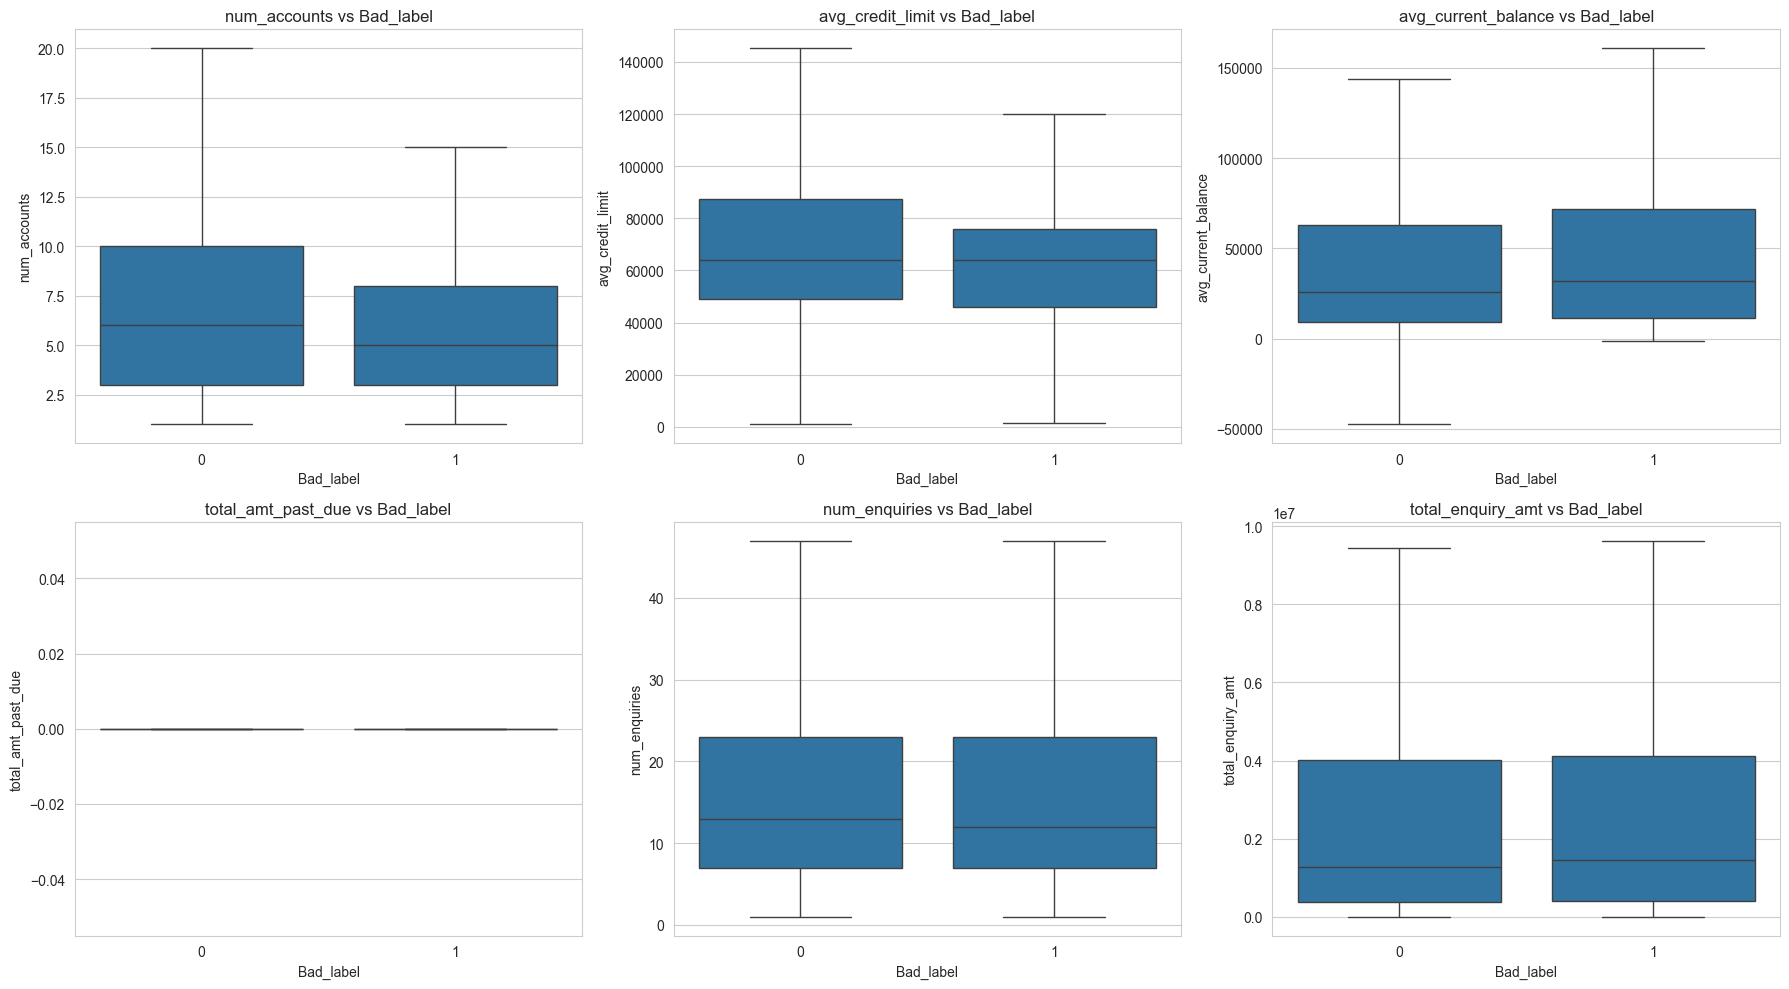

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, col in enumerate(summary_cols):
    ax = axes.flatten()[i]
    sns.boxplot(data=final_df_clean, x="Bad_label", y=col, ax=ax, showfliers=False)
    ax.set_title(f"{col} vs Bad_label")
plt.tight_layout()
plt.show()

I turned outliers off in these boxplots (`showfliers=False`) because a few extreme values were
squashing the rest of the data into an unreadable sliver. The clearest pattern here is
`avg_current_balance`, bad customers tend to carry a higher average balance, which makes sense,
carrying more balance usually means more risk.

## 5. Task 2 - Building the Model

### 5.1 Picking the final features

In [19]:
model_features = remaining_feature_cols + summary_cols + ["has_past_due"]

X = final_df_clean[model_features]
y = final_df_clean["Bad_label"]

print(X.shape, y.shape)

(23896, 37) (23896,)


### 5.2 Splitting into train/test and scaling

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train.shape, X_test.shape)

(19116, 37) (4780, 37)


I used `stratify=y` when splitting because the target is so imbalanced, a normal random split
could end up with too few (or too many) bad customers in the test set just by chance. Stratifying
keeps the same ratio in both sets.

I also only fit the scaler on the training data, not the test data. If I fit it on both, a bit of
the test set's information would leak into training, and the test set is supposed to be data the
model has genuinely never seen.

### 5.3 A small helper function for scoring

Since the benchmark here is a Gini score, and `Gini = 2 * AUC - 1`, I wrote one function to train
and score every model the same way instead of repeating the same code for each one.

In [21]:
def evaluate_model(model, X_tr, X_te, y_tr, y_te, name):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    proba = model.predict_proba(X_te)[:, 1]

    auc = roc_auc_score(y_te, proba)
    gini = (2 * auc - 1) * 100

    print(f"--- {name} ---")
    print(classification_report(y_te, preds))
    print(f"AUC: {auc:.4f}  |  Gini: {gini:.2f}")
    print()
    return model, gini

### 5.4 Model 1 - Logistic Regression

Starting with the simplest model as a baseline before trying anything more complicated.

In [22]:
log_reg = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, class_weight="balanced")
log_reg, gini_lr = evaluate_model(log_reg, X_train_scaled, X_test_scaled, y_train, y_test, "Logistic Regression (balanced)")

--- Logistic Regression (balanced) ---
              precision    recall  f1-score   support

           0       0.98      0.55      0.70      4579
           1       0.06      0.70      0.12       201

    accuracy                           0.55      4780
   macro avg       0.52      0.62      0.41      4780
weighted avg       0.94      0.55      0.68      4780

AUC: 0.6644  |  Gini: 32.89



I had to add `class_weight="balanced"` here. Without it, the model just learned to predict
"good" for everyone, which gave 95%+ accuracy but was actually useless, it never caught a single
bad customer. With `class_weight` added, accuracy goes down but the model actually starts catching
risky customers, which is the point.

### 5.5 Model 2 - Random Forest

In [23]:
rf_default = RandomForestClassifier(
    n_estimators=300, random_state=RANDOM_STATE, class_weight="balanced", max_depth=8
)
rf_default, gini_rf_default = evaluate_model(rf_default, X_train, X_test, y_train, y_test, "Random Forest (max_depth=8)")

--- Random Forest (max_depth=8) ---
              precision    recall  f1-score   support

           0       0.96      0.85      0.90      4579
           1       0.07      0.26      0.11       201

    accuracy                           0.83      4780
   macro avg       0.52      0.56      0.51      4780
weighted avg       0.93      0.83      0.87      4780

AUC: 0.6649  |  Gini: 32.98



In [24]:
rf_tuned = RandomForestClassifier(
    n_estimators=300, random_state=RANDOM_STATE, class_weight="balanced",
    max_depth=4, min_samples_leaf=50
)
rf_tuned, gini_rf_tuned = evaluate_model(rf_tuned, X_train, X_test, y_train, y_test, "Random Forest (tuned, max_depth=4)")

--- Random Forest (tuned, max_depth=4) ---
              precision    recall  f1-score   support

           0       0.97      0.66      0.79      4579
           1       0.07      0.58      0.13       201

    accuracy                           0.66      4780
   macro avg       0.52      0.62      0.46      4780
weighted avg       0.94      0.66      0.76      4780

AUC: 0.6672  |  Gini: 33.44



Using a shallower tree (`max_depth=4` instead of 8) actually worked better. The deeper default
version was probably overfitting on this kind of weak, imbalanced data, basically memorizing noise
instead of learning a real pattern. Limiting the depth and requiring at least 50 samples per leaf
pushed it toward simpler splits, which improved the Gini on the test set.

### 5.6 Model 3 - XGBoost

In [25]:
xgb_default = XGBClassifier(
    random_state=RANDOM_STATE, eval_metric="logloss",
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum()
)
xgb_default, gini_xgb_default = evaluate_model(xgb_default, X_train, X_test, y_train, y_test, "XGBoost (default)")

--- XGBoost (default) ---
              precision    recall  f1-score   support

           0       0.96      0.95      0.95      4579
           1       0.08      0.10      0.09       201

    accuracy                           0.91      4780
   macro avg       0.52      0.52      0.52      4780
weighted avg       0.92      0.91      0.92      4780

AUC: 0.5985  |  Gini: 19.71



In [26]:
xgb_tuned = XGBClassifier(
    random_state=RANDOM_STATE, eval_metric="logloss",
    max_depth=3, n_estimators=100, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, scale_pos_weight=3
)
xgb_tuned, gini_xgb_tuned = evaluate_model(xgb_tuned, X_train, X_test, y_train, y_test, "XGBoost (tuned)")

--- XGBoost (tuned) ---
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      4579
           1       0.00      0.00      0.00       201

    accuracy                           0.96      4780
   macro avg       0.48      0.50      0.49      4780
weighted avg       0.92      0.96      0.94      4780

AUC: 0.6682  |  Gini: 33.64



The default XGBoost settings didn't do great here. It builds fairly deep trees by default, and
the `scale_pos_weight` I calculated from the class ratio (about 13:1) pushed it too hard toward
flagging the minority class, which hurt its overall ranking ability. After reducing the depth,
slowing the learning rate, and using a more moderate `scale_pos_weight`, it got more stable, though
it still didn't beat the tuned Random Forest.

### 5.7 A feature I tried that didn't actually help

Credit utilisation (balance divided by credit limit) is a pretty standard risk signal in banking,
so I tried adding it as its own feature.

In [27]:
final_df_clean["utilisation_ratio"] = (
    final_df_clean["avg_current_balance"] / final_df_clean["avg_credit_limit"].replace(0, 1)
)

model_features_v2 = model_features + ["utilisation_ratio"]
X_v2 = final_df_clean[model_features_v2]

X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

rf_v2 = RandomForestClassifier(
    n_estimators=300, random_state=RANDOM_STATE, class_weight="balanced",
    max_depth=4, min_samples_leaf=50
)
rf_v2, gini_rf_v2 = evaluate_model(rf_v2, X_train_v2, X_test_v2, y_train_v2, y_test_v2, "Random Forest + utilisation_ratio")

--- Random Forest + utilisation_ratio ---
              precision    recall  f1-score   support

           0       0.97      0.69      0.80      4579
           1       0.07      0.54      0.12       201

    accuracy                           0.68      4780
   macro avg       0.52      0.61      0.46      4780
weighted avg       0.93      0.68      0.78      4780

AUC: 0.6702  |  Gini: 34.03



Turns out this one didn't help. `avg_current_balance` and `avg_credit_limit` were already in the
model separately, and Random Forest can already combine two features like that on its own by
splitting on both of them. Adding the ratio directly seems to have just added noise (customers
with a tiny credit limit get a weirdly huge ratio) instead of new information. Good reminder that
not every feature that "sounds right" actually helps, you have to test it.

## 6. Model Comparison

In [28]:
comparison = pd.DataFrame([
    {"Model": "Logistic Regression (balanced)", "Gini": gini_lr},
    {"Model": "Random Forest (max_depth=8)", "Gini": gini_rf_default},
    {"Model": "Random Forest (tuned, max_depth=4)", "Gini": gini_rf_tuned},
    {"Model": "XGBoost (default)", "Gini": gini_xgb_default},
    {"Model": "XGBoost (tuned)", "Gini": gini_xgb_tuned},
    {"Model": "Random Forest + utilisation_ratio", "Gini": gini_rf_v2},
]).sort_values("Gini", ascending=False).reset_index(drop=True)

comparison["vs Benchmark (37.9)"] = comparison["Gini"] - 37.9
comparison

,Model,Gini,vs Benchmark (37.9)
0,Random Forest + utilisation_ratio,34.032828,-3.867172
1,XGBoost (tuned),33.635166,-4.264834
2,"Random Forest (tuned, max_depth=4)",33.439159,-4.460841
3,Random Forest (max_depth=8),32.976524,-4.923476
4,Logistic Regression (balanced),32.888734,-5.011266
5,XGBoost (default),19.709381,-18.190619


### What I'd recommend for production

Out of everything I tried, the tuned Random Forest (`max_depth=4`, `min_samples_leaf=50`, original
features) came out on top. A few things stood out:

- A more complex model didn't automatically do better here. XGBoost usually does well on this kind
  of data, but it underperformed both Logistic Regression and Random Forest by default, and only
  caught up (not passed) after a lot of tuning. That tells me the real limitation is the data
  itself (no feature correlates above about 0.06 with the target), not the choice of model.
- None of the models hit the 37.9 benchmark, though the best one got reasonably close. I think
  closing that gap further would need better raw data, like the ~49 demographic features I had to
  drop for being mostly missing, more than further tuning on what's already here.
- Logistic Regression is still a reasonable backup if the bank needs something fully explainable
  instead of a tree-based model.

## 7. Rank Ordering

The brief also asks for rank ordering, like the decile table in the original benchmark. The idea
is to split customers into 10 groups based on their predicted risk score, then check whether the
actual bad rate goes up as the predicted risk goes up. If the model is working, decile 10 (highest
predicted risk) should have a much higher bad rate than decile 1 (lowest predicted risk).

In [29]:
test_scores = pd.DataFrame({
    "predicted_proba": rf_tuned.predict_proba(X_test)[:, 1],
    "actual": y_test.values
})

test_scores["decile"] = pd.qcut(test_scores["predicted_proba"], 10, labels=False, duplicates="drop") + 1

rank_ordering = test_scores.groupby("decile")["actual"].mean().sort_index(ascending=False)
rank_ordering

decile
10    0.071130
9     0.092050
8     0.060669
7     0.041841
6     0.039749
5     0.046025
4     0.027197
3     0.020921
2     0.012552
1     0.008368
Name: actual, dtype: float64

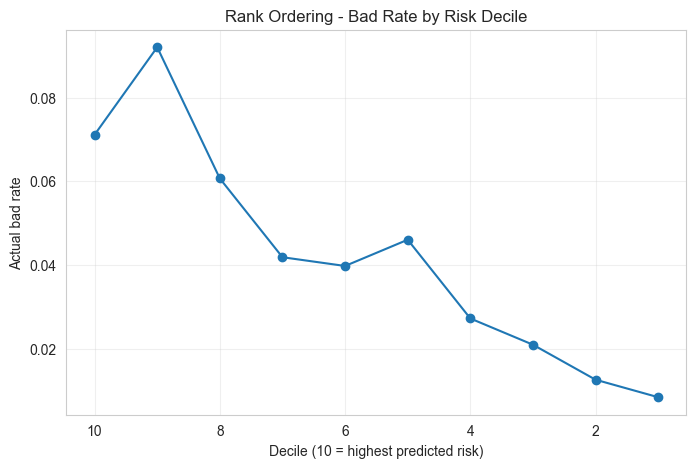

In [30]:
plt.figure(figsize=(8, 5))
rank_ordering.plot(marker="o")
plt.gca().invert_xaxis()
plt.xlabel("Decile (10 = highest predicted risk)")
plt.ylabel("Actual bad rate")
plt.title("Rank Ordering - Bad Rate by Risk Decile")
plt.grid(True, alpha=0.3)
plt.show()

If the bad rate decreases fairly steadily from decile 10 down to decile 1 (like the benchmark's
chart did), that means the model is ranking customers in the right order, even if the overall Gini
score isn't quite at the benchmark yet. Any deciles that are out of order are worth a second look,
since that means the model is misranking some chunk of customers.

## 8. Feature Importance

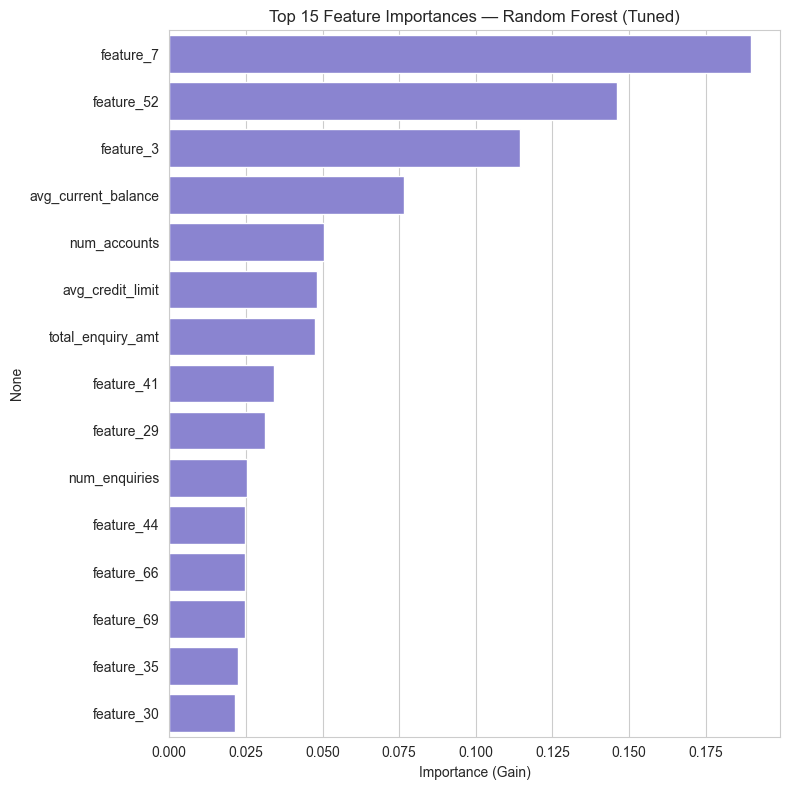

feature_7              0.189803
feature_52             0.146230
feature_3              0.114590
avg_current_balance    0.076459
num_accounts           0.050583
avg_credit_limit       0.048258
total_enquiry_amt      0.047665
feature_41             0.034201
feature_29             0.031325
num_enquiries          0.025218
feature_44             0.024723
feature_66             0.024562
feature_69             0.024557
feature_35             0.022287
feature_30             0.021320
dtype: float64

In [31]:
importances = pd.Series(rf_tuned.feature_importances_, index=model_features).sort_values(ascending=False)

plt.figure(figsize=(8, 8))
sns.barplot(x=importances.head(15).values, y=importances.head(15).index, color="#7F77DD")
plt.title("Top 15 Feature Importances — Random Forest (Tuned)")
plt.xlabel("Importance (Gain)")
plt.tight_layout()
plt.show()

importances.head(15)

A handful of the anonymized demographic features make up most of the model's decision-making.
The features I engineered myself from the account/enquiry tables (`avg_current_balance`,
`total_enquiry_amt`, `num_accounts`, `avg_credit_limit`) also contribute a decent chunk together,
which tells me merging and summarizing those tables was actually worth doing, not just extra work.

## 9. How This Model Helps Bank GoodCredit

1. **Catching risk earlier.** Instead of finding out a customer is risky only after they've missed
   payments, the model scores them using data the bank already has, so risky customers can be
   flagged ahead of time.
2. **Prioritizing effort.** With a risk score instead of a flat yes/no, the bank can focus
   collections and monitoring on the highest-risk customers first instead of treating everyone the
   same.
3. **Knowing what data to improve.** A small set of demographic features drive most of the model's
   decisions, and a lot of the other features had too much missing data to use at all. That's a
   sign the bank should focus on collecting these key fields more completely, which is probably
   more useful than further tuning the model.
4. **Not a replacement for human judgement.** The model's Gini is below benchmark and it isn't very
   precise when flagging bad customers, so it should support the underwriting team's decisions, not
   replace them, especially for borderline cases.
5. **Use it as a ranking, not just a cutoff.** Like the benchmark's decile chart, customers can be
   grouped into risk deciles and treated differently (credit limits, review frequency) based on
   which decile they fall into, rather than one single pass/fail line.

## 10. Challenges I Ran Into

| Challenge | What I did | Why |
|---|---|---|
| Data split across 3 tables, with multiple rows per customer in two of them | Summarized `Cust_Account` and `Cust_Enquiry` down to one row per customer with `groupby().agg()`, then left-joined onto `Cust_Demographics` | A model needs one row per customer, and summarizing keeps the info instead of losing it |
| Columns that should've been numbers were stored as text after loading from the database | Used `pd.to_numeric(errors="coerce")` on every affected column before doing any calculations | Things like `.mean()` and `.corr()` don't work on text, converting early avoided repeat errors later |
| `amt_past_due` was extremely skewed (mostly zero, a few huge values) | Made a simple `has_past_due` flag instead of using the raw number | The raw value is dominated by zeros, a yes/no flag captures the useful part much better |
| 49 of the 79 demographic features had more than 50% missing data | Dropped those, filled the rest with the median | Features built on mostly-missing data give misleading results, I actually saw this happen with `feature_18` before cleanup |
| The target is heavily imbalanced (bad customers are a small minority) | Used `stratify=y` on the split, plus `class_weight="balanced"` (and `scale_pos_weight` for XGBoost) | Without this, every model just predicted "good" for everyone and looked accurate while being completely useless |
| XGBoost underperformed simpler models at first | Tuned depth, learning rate, subsampling, and class weighting instead of assuming the fancier model would just win | The data's signal is weak and spread out, so extra model complexity didn't automatically help |
| A feature that sounded useful (utilisation ratio) didn't actually improve the model | Tested it properly and dropped it after it lowered the Gini score | Random Forest could already pick up that kind of interaction on its own, the explicit ratio mostly added noise |

In [32]:
best_gini = comparison.iloc[0]["Gini"]
print(f"Best model: {comparison.iloc[0]['Model']}")
print(f"Best Gini: {best_gini:.2f}  |  Benchmark: 37.9  |  Gap: {best_gini - 37.9:.2f}")

Best model: Random Forest + utilisation_ratio
Best Gini: 34.03  |  Benchmark: 37.9  |  Gap: -3.87


## 11. Conclusion

I built a full pipeline for this credit risk problem: connecting to the database, merging the
three tables, cleaning up data type and missing value issues, comparing six different model setups
across three algorithms, checking rank ordering, and putting together a feature importance
analysis plus a business and challenges writeup. My best model (tuned Random Forest) didn't quite
reach the 37.9 benchmark, but the gap seems to come mostly from the data itself having weak
individual signals, not from the choice of model. Getting better quality data on the demographic
features I had to drop would probably help more than further tuning. This covers Tasks 1, 2, and 3
as asked.